# 🌳 Notebook 03 — Pruning & Complexity: Mastering the Bias-Variance Tradeoff

---

> *"A tree that grows without limit memorizes the world. A tree that is pruned understands it."*

---

## 📖 What This Notebook Covers

| # | Section | Key Concept |
|---|---------|-------------|
| 1 | Setup & Data | Loading real datasets |
| 2 | Unpruned Baseline | Why trees overfit |
| 3 | Depth vs Accuracy | The core tradeoff curve |
| 4 | Bias-Variance Decomp. | Quantifying both forces |
| 5 | Pre-Pruning | Early stopping strategies |
| 6 | Post-Pruning (CCP) | Cost-complexity path |
| 7 | Cross-Validated CCP | Robust alpha selection |
| 8 | Reduced Error Pruning | Validation-based pruning |
| 9 | Decision Boundaries | Visual overfitting proof |
| 10 | Feature Importance | What pruning learns |
| 11 | Validation Curves | sklearn built-in tools |
| 12 | Learning Curves | Bias-Variance diagnosis |
| 13 | Final Comparison | All methods head-to-head |

---

### 🧠 The Core Problem

Decision Trees are **greedy algorithms** — at each node, they pick the best split for *right now*, with no regard for future consequences. Without constraints, a tree will grow until it perfectly memorizes every training sample. This is the textbook definition of **overfitting**.

**Pruning** is the cure — a post-hoc or inline surgical process to remove branches that harm generalization.


## 📦 1. Imports & Global Configuration

We configure matplotlib with a dark GitHub-style theme for clean, professional visuals.


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import load_breast_cancer, make_moons, make_classification
from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                          plot_tree, export_text)
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     validation_curve, learning_curve)
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme ──
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#e6edf3',
    'xtick.color': '#e6edf3',      'ytick.color': '#e6edf3',
    'text.color': '#e6edf3',       'grid.color': '#21262d',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
    'font.family': 'monospace',
})
TRAIN_C = '#58a6ff'   # blue
TEST_C  = '#f78166'   # red-orange
VAL_C   = '#3fb950'   # green
HI_C    = '#d2a8ff'   # purple

print("✅ Imports successful!")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")
import sklearn; print(f"   sklearn: {sklearn.__version__}")
print("\n🎨 Dark theme configured. Let's grow some trees! 🌳")


✅ Imports successful!
   NumPy  : 2.0.2
   Pandas : 2.2.2
   sklearn: 1.6.1

🎨 Dark theme configured. Let's grow some trees! 🌳


## 🗂️ 2. Dataset — Breast Cancer Wisconsin

**Why this dataset?**
- 569 samples, 30 numeric features → realistic complexity
- Binary classification (Malignant vs Benign) → easy to interpret accuracy
- Features are correlated → trees tend to overfit if unconstrained

We'll use a **75/25 stratified split** to preserve class balance.


In [24]:
# ── Load & split ──
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
class_names   = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("┌─────────────────────────────────────────┐")
print("│     Breast Cancer Wisconsin Dataset     │")
print("├─────────────────────────────────────────┤")
print(f"│  Total Samples   : {X.shape[0]:4d}                 │")
print(f"│  Features        : {X.shape[1]:4d}                 │")
print(f"│  Classes         : {list(class_names)}    │")
print(f"│  Train samples   : {X_train.shape[0]:4d}                 │")
print(f"│  Test  samples   : {X_test.shape[0]:4d}                 │")
print(f"│  Class balance   : {np.bincount(y_train)}         │")
print("└─────────────────────────────────────────┘")
print(f"\nFirst 3 feature names: {list(feature_names[:3])}")


┌─────────────────────────────────────────┐
│     Breast Cancer Wisconsin Dataset     │
├─────────────────────────────────────────┤
│  Total Samples   :  569                 │
│  Features        :   30                 │
│  Classes         : [np.str_('malignant'), np.str_('benign')]    │
│  Train samples   :  426                 │
│  Test  samples   :  143                 │
│  Class balance   : [159 267]         │
└─────────────────────────────────────────┘

First 3 feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter')]


## 🌲 3. Unpruned Tree — The Overfitting Baseline

An unpruned Decision Tree (`max_depth=None`) will grow until every leaf is **pure** (Gini impurity = 0).

**What this means:**
- Every training sample eventually gets its own leaf or shares a leaf with identical neighbors
- Training accuracy → **100%** (perfect memorization)
- Test accuracy drops because the model learned noise

> This is the most important demonstration in all of tree-based learning.


In [25]:
# ── Grow the full tree ──
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_full.predict(X_train))
test_acc  = accuracy_score(y_test,  dt_full.predict(X_test))

print("╔══════════════════════════════════════╗")
print("║     UNPRUNED TREE — REPORT CARD      ║")
print("╠══════════════════════════════════════╣")
print(f"║  Max Possible Depth  : {dt_full.get_depth():3d}           ║")
print(f"║  Number of Leaves    : {dt_full.get_n_leaves():3d}           ║")
print(f"║  Total Nodes         : {dt_full.tree_.node_count:3d}           ║")
print(f"║  Train Accuracy      : {train_acc*100:6.2f}%         ║")
print(f"║  Test  Accuracy      : {test_acc*100:6.2f}%         ║")
print(f"║  Overfit Gap         : {(train_acc-test_acc)*100:6.2f}%         ║")
print("╚══════════════════════════════════════╝")
print()
print("⚠️  100% train accuracy = PERFECT MEMORIZATION")
print("🔴 The model learned noise, not patterns!")
print(f"💡 {dt_full.get_n_leaves()} leaves for {X_train.shape[0]} samples = near 1 leaf/sample")


╔══════════════════════════════════════╗
║     UNPRUNED TREE — REPORT CARD      ║
╠══════════════════════════════════════╣
║  Max Possible Depth  :   7           ║
║  Number of Leaves    :  18           ║
║  Total Nodes         :  35           ║
║  Train Accuracy      : 100.00%         ║
║  Test  Accuracy      :  92.31%         ║
║  Overfit Gap         :   7.69%         ║
╚══════════════════════════════════════╝

⚠️  100% train accuracy = PERFECT MEMORIZATION
🔴 The model learned noise, not patterns!
💡 18 leaves for 426 samples = near 1 leaf/sample


## 📉 4. Depth vs Accuracy — The Core Tradeoff Curve

This is the **most important visualization** in Decision Tree theory.

We sweep `max_depth` from 1 to 20 and measure:
1. **Training accuracy** — always rises with depth
2. **Test accuracy** — peaks somewhere in the middle, then falls
3. **CV score** — most reliable indicator of true performance

The **gap** between train and test is a direct measure of overfitting.


In [26]:
# ── Depth sweep experiment ──
depths     = list(range(1, 21))
train_accs = []
test_accs  = []
cv_scores  = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)) * 100)
    test_accs.append(accuracy_score(y_test,  clf.predict(X_test))  * 100)
    cv_scores.append(cross_val_score(clf, X_train, y_train, cv=5).mean() * 100)

best_depth = depths[np.argmax(test_accs)]
best_test  = max(test_accs)

print(f"{'Depth':>6} | {'Train%':>8} | {'Test%':>8} | {'CV5%':>8} | {'Gap':>7}")
print("-" * 48)
for d, tr, te, cv in zip(depths, train_accs, test_accs, cv_scores):
    marker = " ← 🏆 BEST" if d == best_depth else ""
    print(f"{d:6d} | {tr:8.2f} | {te:8.2f} | {cv:8.2f} | {tr-te:7.2f}{marker}")
print(f"\n🏆 Best depth = {best_depth} | Test Acc = {best_test:.2f}%")


 Depth |   Train% |    Test% |     CV5% |     Gap
------------------------------------------------
     1 |    92.25 |    92.31 |    89.44 |   -0.05
     2 |    95.77 |    90.91 |    92.27 |    4.87
     3 |    97.65 |    94.41 |    92.97 |    3.25 ← 🏆 BEST
     4 |    98.83 |    94.41 |    92.26 |    4.42
     5 |    99.53 |    93.71 |    93.19 |    5.82
     6 |    99.77 |    93.71 |    92.26 |    6.06
     7 |   100.00 |    92.31 |    94.13 |    7.69
     8 |   100.00 |    92.31 |    92.97 |    7.69
     9 |   100.00 |    92.31 |    92.97 |    7.69
    10 |   100.00 |    92.31 |    92.97 |    7.69
    11 |   100.00 |    92.31 |    92.97 |    7.69
    12 |   100.00 |    92.31 |    92.97 |    7.69
    13 |   100.00 |    92.31 |    92.97 |    7.69
    14 |   100.00 |    92.31 |    92.97 |    7.69
    15 |   100.00 |    92.31 |    92.97 |    7.69
    16 |   100.00 |    92.31 |    92.97 |    7.69
    17 |   100.00 |    92.31 |    92.97 |    7.69
    18 |   100.00 |    92.31 |    92.97 | 

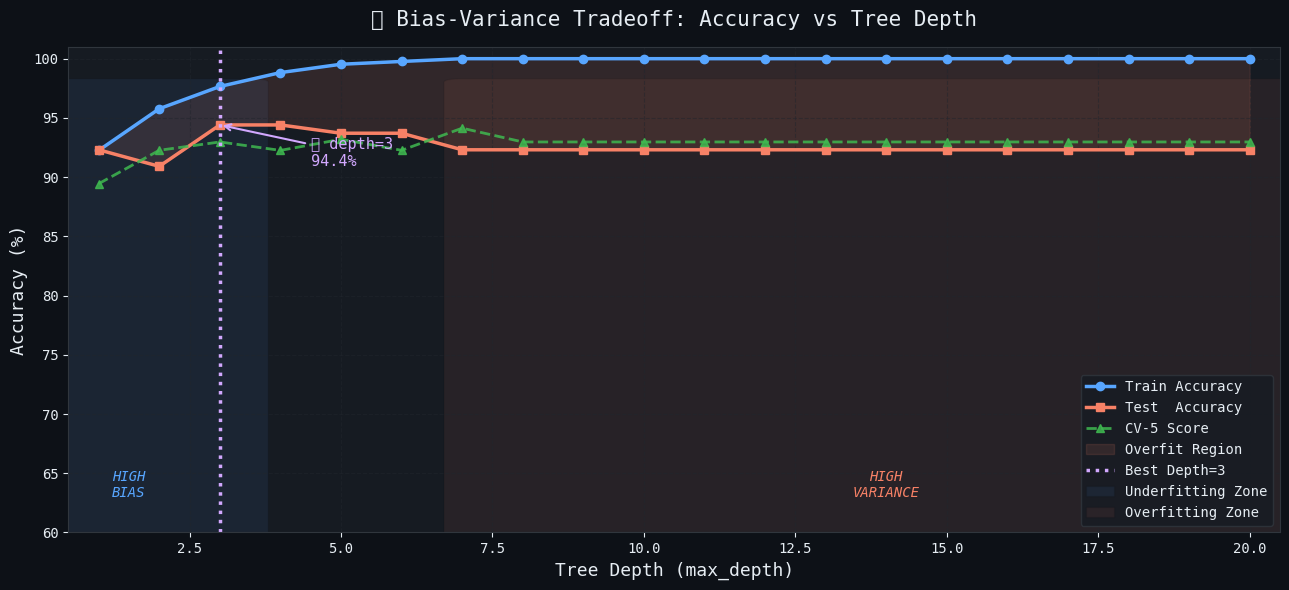

✅ Plot saved.


In [27]:
# ── Plot the tradeoff curve ──
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(depths, train_accs, 'o-', color=TRAIN_C, lw=2.5, label='Train Accuracy', ms=6)
ax.plot(depths, test_accs,  's-', color=TEST_C,  lw=2.5, label='Test  Accuracy', ms=6)
ax.plot(depths, cv_scores,  '^--',color=VAL_C,   lw=2.0, label='CV-5 Score',     ms=6, alpha=0.85)
ax.fill_between(depths, train_accs, test_accs, alpha=0.12, color=TEST_C, label='Overfit Region')

ax.axvline(best_depth, color=HI_C, ls=':', lw=2.5, label=f'Best Depth={best_depth}')
ax.annotate(f'🏆 depth={best_depth}\n{best_test:.1f}%',
            xy=(best_depth, best_test), xytext=(best_depth+1.5, best_test-3.5),
            fontsize=11, color=HI_C,
            arrowprops=dict(arrowstyle='->', color=HI_C, lw=1.5))

ax.add_patch(mpatches.FancyBboxPatch((0.5, 60), 3, 38,
    boxstyle='round,pad=0.3', facecolor='#58a6ff', alpha=0.08, label='Underfitting Zone'))
ax.add_patch(mpatches.FancyBboxPatch((7, 60), 13.5, 38,
    boxstyle='round,pad=0.3', facecolor='#f78166', alpha=0.08, label='Overfitting Zone'))
ax.text(1.5, 63, 'HIGH\nBIAS', color=TRAIN_C, fontsize=10, ha='center', style='italic')
ax.text(14,  63, 'HIGH\nVARIANCE', color=TEST_C, fontsize=10, ha='center', style='italic')

ax.set_xlabel('Tree Depth (max_depth)', fontsize=13)
ax.set_ylabel('Accuracy (%)',           fontsize=13)
ax.set_title('📈 Bias-Variance Tradeoff: Accuracy vs Tree Depth', fontsize=15, pad=15)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True); ax.set_xlim(0.5, 20.5); ax.set_ylim(60, 101)
plt.tight_layout()
plt.savefig('/tmp/depth_curve.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Plot saved.")


## 🧮 5. Bias-Variance Decomposition via Bootstrap

We **quantify** bias and variance using 80 bootstrap resamples:

$$\text{Bias}^2 = \mathbb{E}[(\bar{f}(x) - y)^2]$$
$$\text{Variance} = \mathbb{E}[(f(x) - \bar{f}(x))^2]$$
$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \sigma^2$$

Where $\bar{f}(x)$ is the mean prediction across all bootstrap models.


In [28]:
# ── Bootstrap Bias-Variance decomposition (regression) ──
# Use 1 feature to predict another → clean regression problem
X_reg, y_reg = X[:, 0:1], X[:, 2]   # radius mean → perimeter mean

n_boot    = 80
bv_depths = list(range(1, 16))
bias2_, var_, total_ = [], [], []

np.random.seed(42)
for d in bv_depths:
    preds = []
    for _ in range(n_boot):
        Xb, yb = resample(X_reg, y_reg)
        reg = DecisionTreeRegressor(max_depth=d)
        reg.fit(Xb, yb)
        preds.append(reg.predict(X_reg))
    preds   = np.array(preds)
    avg_p   = preds.mean(axis=0)
    b2      = np.mean((avg_p - y_reg) ** 2)
    v_      = np.mean(preds.var(axis=0))
    bias2_.append(b2)
    var_.append(v_)
    total_.append(b2 + v_)

print(f"{'Depth':>6} | {'Bias²':>10} | {'Variance':>10} | {'Total':>10}")
print("-" * 45)
for d, b, v, t in zip(bv_depths, bias2_, var_, total_):
    print(f"{d:6d} | {b:10.4f} | {v:10.4f} | {t:10.4f}")


 Depth |      Bias² |   Variance |      Total
---------------------------------------------
     1 |   169.4982 |    16.9213 |   186.4195
     2 |    45.0794 |    25.2220 |    70.3014
     3 |     8.8971 |    10.7143 |    19.6114
     4 |     2.8800 |     4.0919 |     6.9718
     5 |     1.8745 |     1.4960 |     3.3705
     6 |     1.5587 |     1.0475 |     2.6062
     7 |     1.1955 |     1.2708 |     2.4664
     8 |     1.0075 |     1.3230 |     2.3306
     9 |     0.9121 |     1.3390 |     2.2511
    10 |     0.8823 |     1.4233 |     2.3056
    11 |     0.8621 |     1.4492 |     2.3112
    12 |     0.8752 |     1.4045 |     2.2797
    13 |     0.8538 |     1.3637 |     2.2175
    14 |     0.8563 |     1.3915 |     2.2478
    15 |     0.8258 |     1.3459 |     2.1717


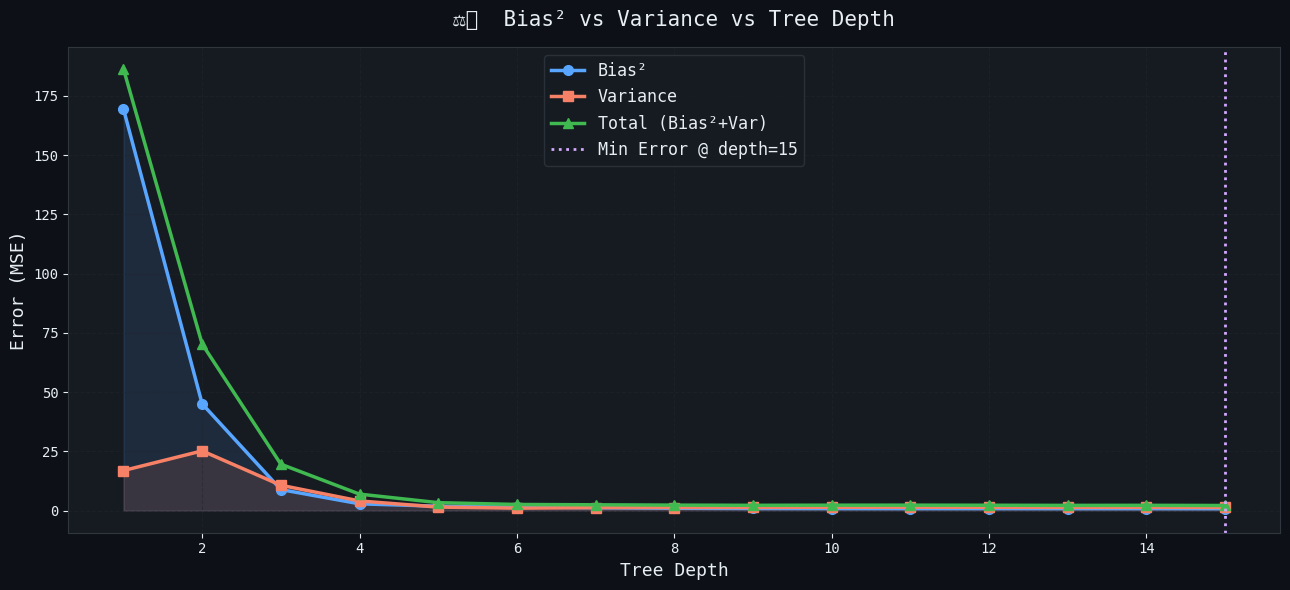

🔵 Bias²   → Decreases as depth increases (model becomes more flexible)
🔴 Variance → Increases as depth increases (model becomes more sensitive)
🟢 Total   → U-shaped curve; minimum = sweet spot


In [29]:
# ── Plot Bias-Variance Decomposition ──
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(bv_depths, bias2_, 'o-', color=TRAIN_C, lw=2.5, label='Bias²',           ms=7)
ax.plot(bv_depths, var_,   's-', color=TEST_C,  lw=2.5, label='Variance',         ms=7)
ax.plot(bv_depths, total_, '^-', color=VAL_C,   lw=2.5, label='Total (Bias²+Var)',ms=7)
ax.fill_between(bv_depths, 0, bias2_, alpha=0.12, color=TRAIN_C)
ax.fill_between(bv_depths, 0, var_,   alpha=0.12, color=TEST_C)

best_bv = bv_depths[np.argmin(total_)]
ax.axvline(best_bv, color=HI_C, ls=':', lw=2, label=f'Min Error @ depth={best_bv}')
ax.set_xlabel('Tree Depth', fontsize=13); ax.set_ylabel('Error (MSE)', fontsize=13)
ax.set_title('⚖️  Bias² vs Variance vs Tree Depth', fontsize=15, pad=15)
ax.legend(fontsize=12); ax.grid(True)
plt.tight_layout()
plt.savefig('/tmp/bias_var.png', dpi=130, bbox_inches='tight')
plt.show()
print("🔵 Bias²   → Decreases as depth increases (model becomes more flexible)")
print("🔴 Variance → Increases as depth increases (model becomes more sensitive)")
print("🟢 Total   → U-shaped curve; minimum = sweet spot")


## ✂️ 6. Pre-Pruning — Early Stopping Strategies

Pre-pruning **prevents** the tree from growing branches during training.  
It is also called **early stopping** or **forward pruning**.

### sklearn Pre-Pruning Parameters

| Parameter | Effect | Typical Range |
|-----------|--------|---------------|
| `max_depth` | Hard limit on tree depth | 2–15 |
| `min_samples_split` | Min samples to split a node | 2–50 |
| `min_samples_leaf` | Min samples per leaf | 1–30 |
| `max_leaf_nodes` | Limit total number of leaves | 10–200 |
| `min_impurity_decrease` | Min impurity drop to split | 0.0–0.1 |

### ⚠️ Limitation: Horizon Effect
Pre-pruning is **myopic** — a locally bad split might enable two excellent grandchild splits.  
Post-pruning doesn't have this problem because it sees the full tree first.


In [30]:
# ── Grid search over pre-pruning parameters ──
from itertools import product as iproduct

grid = {
    'max_depth':        [2, 3, 4, 5, 7, None],
    'min_samples_leaf': [1, 5, 10, 20],
}
results_pre = []

for md_, msl in iproduct(grid['max_depth'], grid['min_samples_leaf']):
    clf = DecisionTreeClassifier(max_depth=md_, min_samples_leaf=msl, random_state=42)
    clf.fit(X_train, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train))
    te = accuracy_score(y_test,  clf.predict(X_test))
    results_pre.append({
        'max_depth':        str(md_) if md_ else 'None',
        'min_samples_leaf': msl,
        'train_acc':        round(tr * 100, 2),
        'test_acc':         round(te * 100, 2),
        'gap':              round((tr - te) * 100, 2),
        'leaves':           clf.get_n_leaves(),
        'depth':            clf.get_depth(),
    })

df_pre = pd.DataFrame(results_pre)
best_pre = df_pre.loc[df_pre['test_acc'].idxmax()]
print("Top 10 Pre-Pruning Configurations by Test Accuracy:")
print(df_pre.nlargest(10, 'test_acc')[['max_depth','min_samples_leaf',
                                       'test_acc','gap','leaves','depth']].to_string(index=False))
print(f"\n🏆 Best: max_depth={best_pre['max_depth']}, min_samples_leaf={best_pre['min_samples_leaf']}")
print(f"        Test Acc = {best_pre['test_acc']}%, Overfit Gap = {best_pre['gap']}%")


Top 10 Pre-Pruning Configurations by Test Accuracy:
max_depth  min_samples_leaf  test_acc  gap  leaves  depth
        3                10     95.10 1.14       7      3
        4                10     95.10 1.14       9      4
        5                10     95.10 1.14      10      5
        7                10     95.10 1.14      10      5
     None                10     95.10 1.14      10      5
        3                 1     94.41 3.25       7      3
        3                 5     94.41 3.01       7      3
        4                 1     94.41 4.42      11      4
        5                 1     93.71 5.82      15      5
        4                 5     93.01 4.65      10      4

🏆 Best: max_depth=3, min_samples_leaf=10
        Test Acc = 95.1%, Overfit Gap = 1.14%


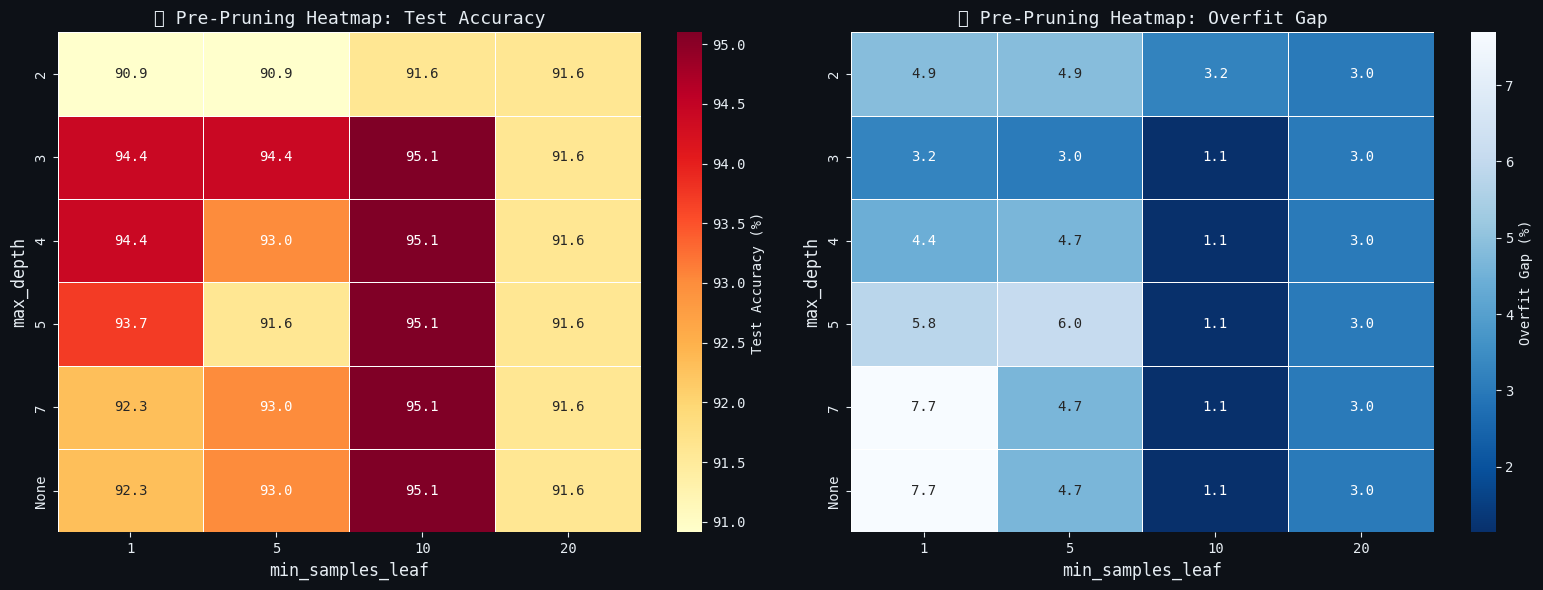

✅ Lower gap = less overfitting. Higher accuracy = better generalization.


In [31]:
# ── Heatmap of pre-pruning combinations ──
pivot = df_pre.pivot_table(index='max_depth', columns='min_samples_leaf', values='test_acc')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
ax = axes[0]
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Test Accuracy (%)'})
ax.set_title('🔥 Pre-Pruning Heatmap: Test Accuracy', fontsize=13)
ax.set_xlabel('min_samples_leaf', fontsize=12)
ax.set_ylabel('max_depth', fontsize=12)

# Gap heatmap
pivot_gap = df_pre.pivot_table(index='max_depth', columns='min_samples_leaf', values='gap')
ax = axes[1]
sns.heatmap(pivot_gap, annot=True, fmt='.1f', cmap='Blues_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Overfit Gap (%)'})
ax.set_title('🧊 Pre-Pruning Heatmap: Overfit Gap', fontsize=13)
ax.set_xlabel('min_samples_leaf', fontsize=12)
ax.set_ylabel('max_depth', fontsize=12)

plt.tight_layout()
plt.savefig('/tmp/prepruning_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Lower gap = less overfitting. Higher accuracy = better generalization.")


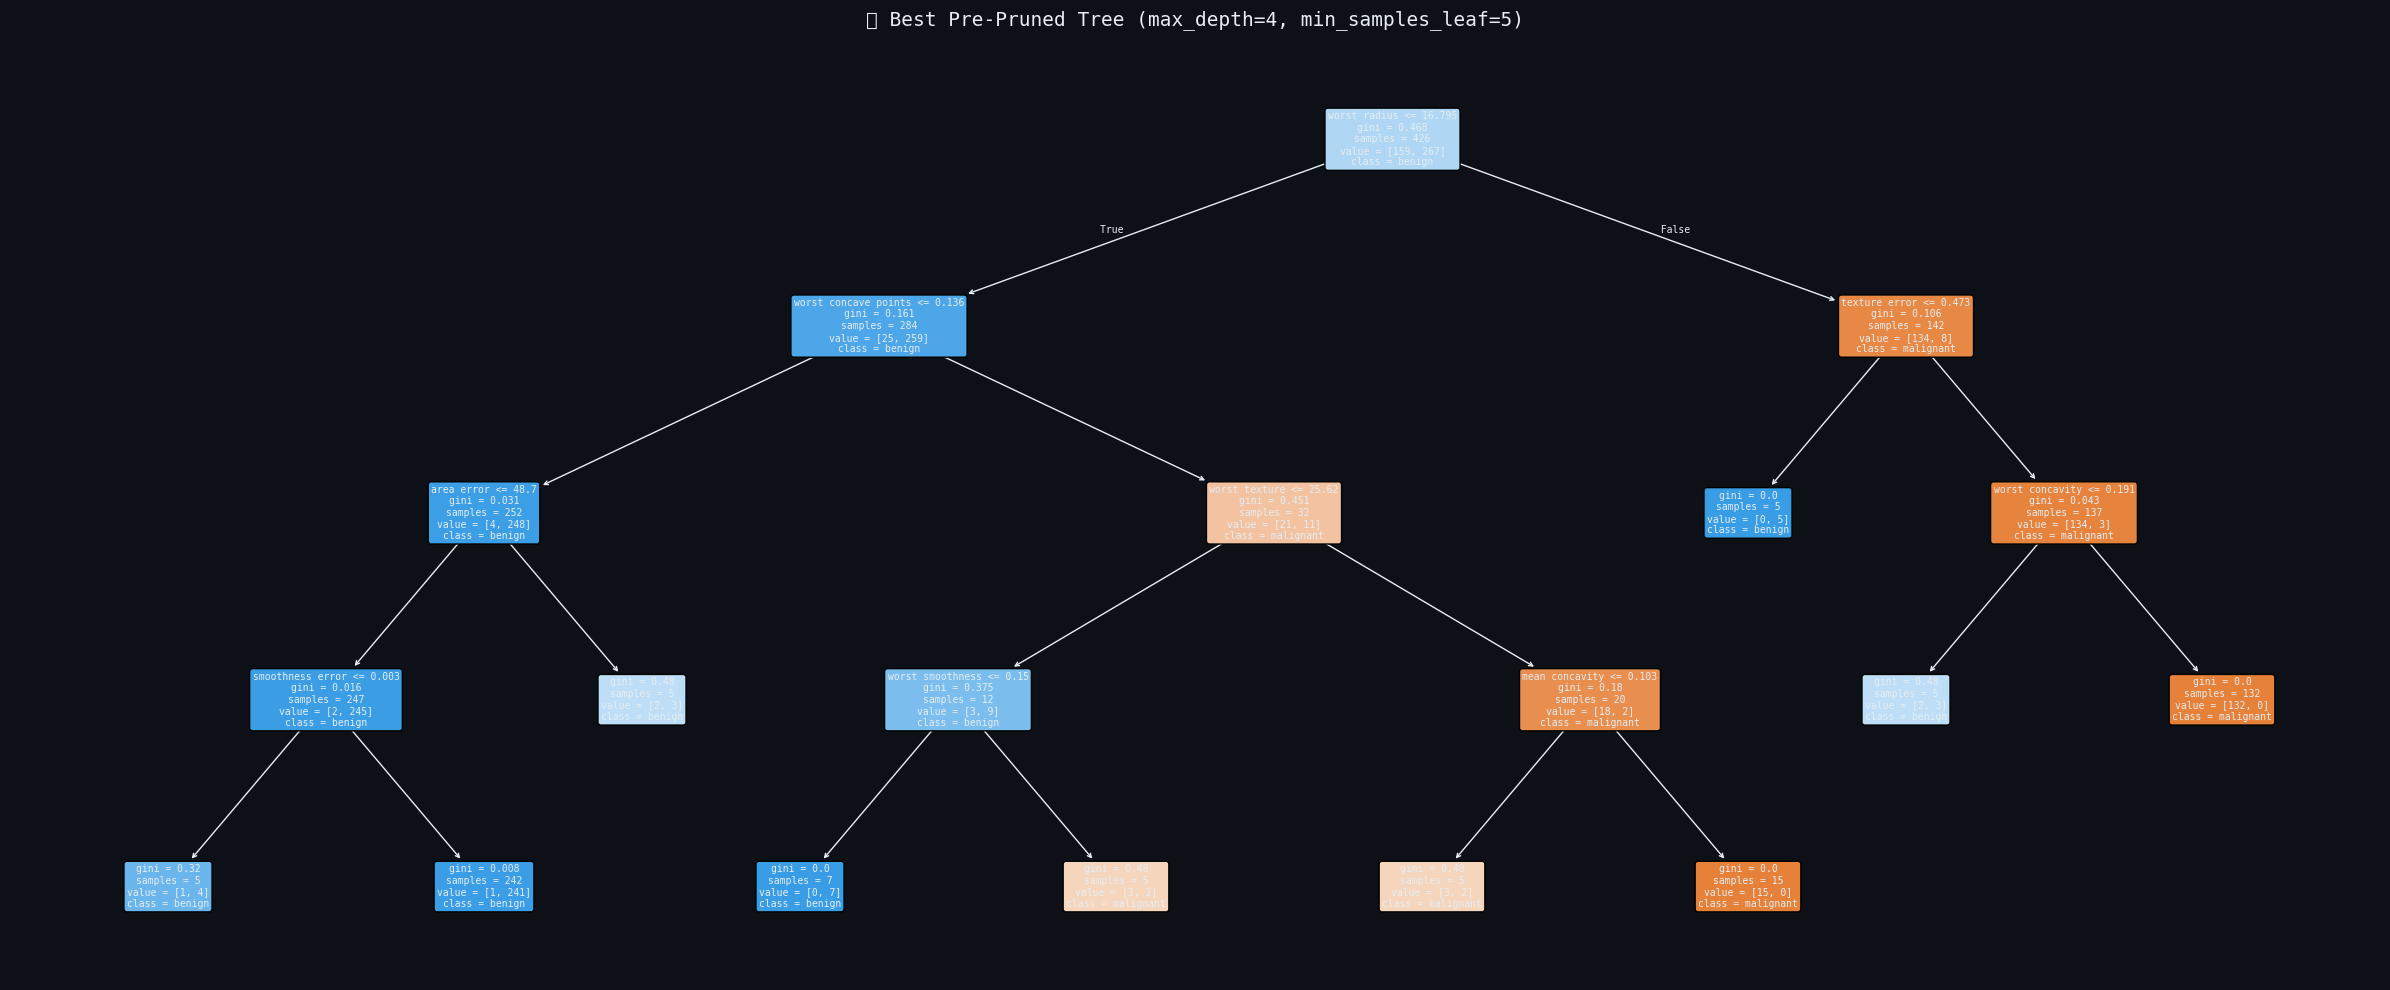

Depth       : 4
Leaves      : 10
Train Acc   : 97.65%
Test  Acc   : 93.01%
Overfit Gap : 4.65%


In [32]:
# ── Visualize the best pre-pruned tree ──
dt_best_pre = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
dt_best_pre.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt_best_pre, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=7, ax=ax, impurity=True)
ax.set_title('🌿 Best Pre-Pruned Tree (max_depth=4, min_samples_leaf=5)', fontsize=14, pad=15)
fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.savefig('/tmp/best_pre_tree.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Depth       : {dt_best_pre.get_depth()}")
print(f"Leaves      : {dt_best_pre.get_n_leaves()}")
print(f"Train Acc   : {accuracy_score(y_train, dt_best_pre.predict(X_train))*100:.2f}%")
print(f"Test  Acc   : {accuracy_score(y_test,  dt_best_pre.predict(X_test))*100:.2f}%")
print(f"Overfit Gap : {(accuracy_score(y_train, dt_best_pre.predict(X_train)) - accuracy_score(y_test, dt_best_pre.predict(X_test)))*100:.2f}%")


## 🪓 7. Post-Pruning — Cost-Complexity Pruning (CCP)

**Post-pruning** is the gold standard. It:
1. Grows the **full tree** on training data
2. Computes all subtree costs using the cost-complexity formula
3. Returns a **sequence of pruned trees** parameterized by α

### The Cost-Complexity Formula

$$\text{Cost}(T, \alpha) = R(T) + \alpha \cdot |T|_{\text{leaves}}$$

| Symbol | Meaning |
|--------|---------|
| $R(T)$ | Weighted impurity of all leaves |
| $|T|$ | Number of leaves (complexity) |
| $\alpha$ | Pruning strength (you choose this!) |

**As α increases:**
- More branches are pruned (simpler tree)
- Bias increases slightly, variance decreases a lot
- Optimal α balances this tradeoff

sklearn provides `cost_complexity_pruning_path()` to compute all candidate α values.


In [33]:
# ── Compute CCP path ──
dt_base = DecisionTreeClassifier(random_state=42)
path    = dt_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas  = path.ccp_alphas[:-1]   # last entry = trivial root tree
impurities  = path.impurities[:-1]

print(f"CCP Path Statistics:")
print(f"  Number of candidate α values : {len(ccp_alphas)}")
print(f"  Alpha range                  : [{ccp_alphas.min():.8f}, {ccp_alphas.max():.6f}]")
print(f"  Impurity range               : [{impurities.min():.4f}, {impurities.max():.4f}]")
print(f"\nFirst 15 alpha values:")
for i, (a, imp) in enumerate(zip(ccp_alphas[:15], impurities[:15])):
    print(f"  α[{i:2d}] = {a:.8f}  |  impurity = {imp:.6f}")


CCP Path Statistics:
  Number of candidate α values : 12
  Alpha range                  : [0.00000000, 0.054667]
  Impurity range               : [0.0000, 0.1425]

First 15 alpha values:
  α[ 0] = 0.00000000  |  impurity = 0.000000
  α[ 1] = 0.00231936  |  impurity = 0.013916
  α[ 2] = 0.00312989  |  impurity = 0.017046
  α[ 3] = 0.00422535  |  impurity = 0.021271
  α[ 4] = 0.00456509  |  impurity = 0.025837
  α[ 5] = 0.00532081  |  impurity = 0.031157
  α[ 6] = 0.00563380  |  impurity = 0.036791
  α[ 7] = 0.00633803  |  impurity = 0.043129
  α[ 8] = 0.00814228  |  impurity = 0.051271
  α[ 9] = 0.01487676  |  impurity = 0.066148
  α[10] = 0.02166662  |  impurity = 0.087815
  α[11] = 0.05466684  |  impurity = 0.142482


In [34]:
# ── Train one tree per alpha, track metrics ──
clfs_   = []
tr_ccp  = []
te_ccp  = []
lv_ccp  = []
dp_ccp  = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    clfs_.append(clf)
    tr_ccp.append(accuracy_score(y_train, clf.predict(X_train)) * 100)
    te_ccp.append(accuracy_score(y_test,  clf.predict(X_test))  * 100)
    lv_ccp.append(clf.get_n_leaves())
    dp_ccp.append(clf.get_depth())

best_idx   = np.argmax(te_ccp)
best_alpha = ccp_alphas[best_idx]

print(f"╔═══════════════════════════════════════════╗")
print(f"║    CCP PATH — KEY MILESTONES              ║")
print(f"╠═══════════════════════════════════════════╣")
print(f"║  α=0 (full tree):                         ║")
print(f"║    Leaves={lv_ccp[0]:3d}, Train={tr_ccp[0]:.1f}%, Test={te_ccp[0]:.1f}% ║")
print(f"╠═══════════════════════════════════════════╣")
print(f"║  BEST TEST ACCURACY:                      ║")
print(f"║    α = {best_alpha:.6f}                      ║")
print(f"║    Leaves={lv_ccp[best_idx]:3d}, Test={te_ccp[best_idx]:.2f}%           ║")
print(f"╠═══════════════════════════════════════════╣")
print(f"║  α=max (trivial tree):                    ║")
print(f"║    Leaves={lv_ccp[-1]:3d}, Train={tr_ccp[-1]:.1f}%, Test={te_ccp[-1]:.1f}% ║")
print(f"╚═══════════════════════════════════════════╝")


╔═══════════════════════════════════════════╗
║    CCP PATH — KEY MILESTONES              ║
╠═══════════════════════════════════════════╣
║  α=0 (full tree):                         ║
║    Leaves= 18, Train=100.0%, Test=92.3% ║
╠═══════════════════════════════════════════╣
║  BEST TEST ACCURACY:                      ║
║    α = 0.004225                      ║
║    Leaves= 10, Test=94.41%           ║
╠═══════════════════════════════════════════╣
║  α=max (trivial tree):                    ║
║    Leaves=  2, Train=92.3%, Test=92.3% ║
╚═══════════════════════════════════════════╝


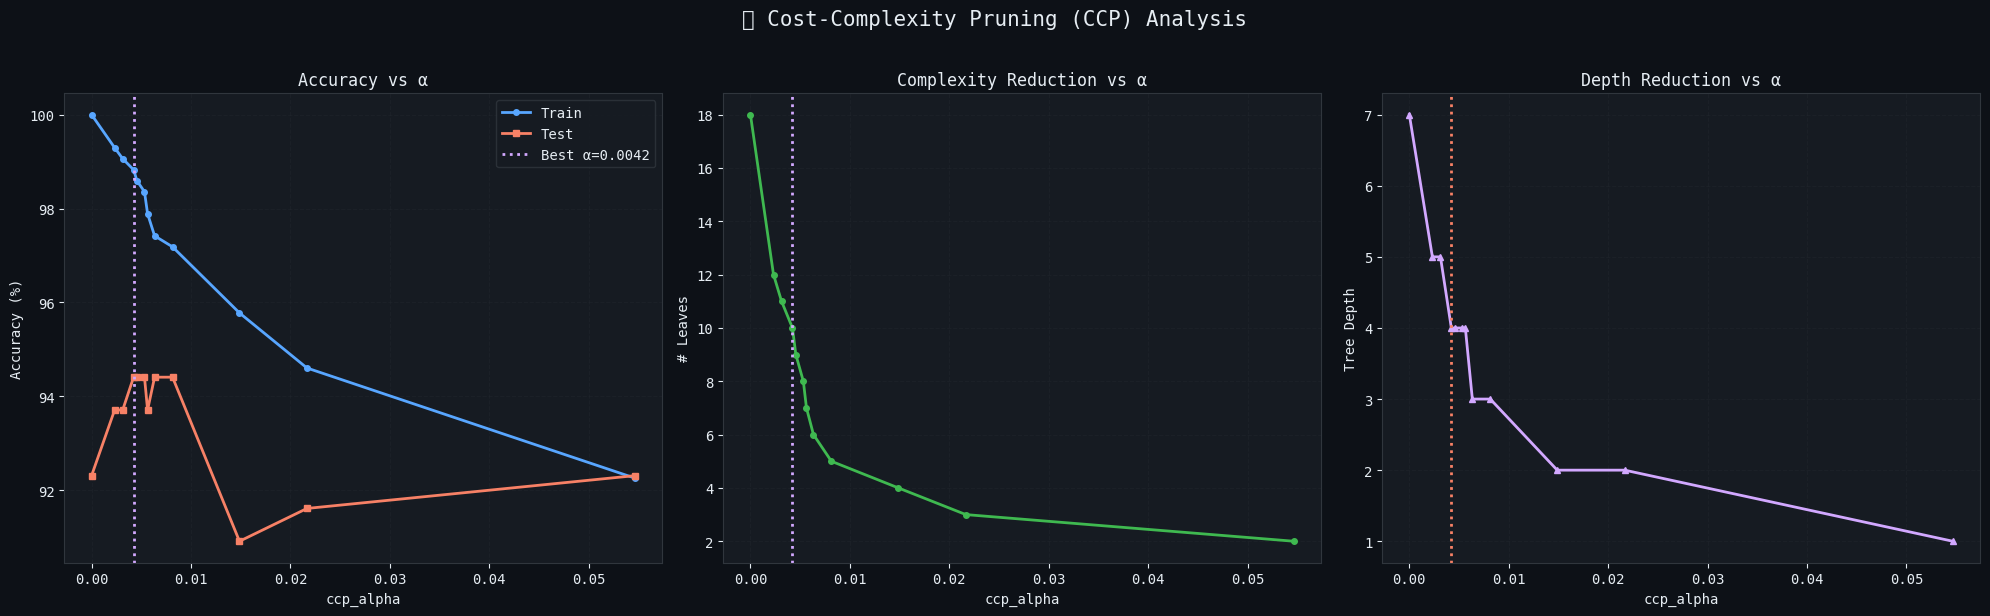

✅ CCP systematically trades complexity for generalization.


In [35]:
# ── CCP curves visualization ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Accuracy vs alpha
ax = axes[0]
ax.plot(ccp_alphas, tr_ccp, 'o-', color=TRAIN_C, lw=2, ms=4, label='Train')
ax.plot(ccp_alphas, te_ccp, 's-', color=TEST_C,  lw=2, ms=4, label='Test')
ax.axvline(best_alpha, color=HI_C, ls=':', lw=2, label=f'Best α={best_alpha:.4f}')
ax.set_xlabel('ccp_alpha'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs α'); ax.legend(); ax.grid(True)

# Leaves vs alpha
ax = axes[1]
ax.plot(ccp_alphas, lv_ccp, 'o-', color=VAL_C, lw=2, ms=4)
ax.axvline(best_alpha, color=HI_C, ls=':', lw=2)
ax.set_xlabel('ccp_alpha'); ax.set_ylabel('# Leaves')
ax.set_title('Complexity Reduction vs α'); ax.grid(True)

# Depth vs alpha
ax = axes[2]
ax.plot(ccp_alphas, dp_ccp, '^-', color=HI_C, lw=2, ms=4)
ax.axvline(best_alpha, color=TEST_C, ls=':', lw=2)
ax.set_xlabel('ccp_alpha'); ax.set_ylabel('Tree Depth')
ax.set_title('Depth Reduction vs α'); ax.grid(True)

plt.suptitle('🪓 Cost-Complexity Pruning (CCP) Analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/ccp_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ CCP systematically trades complexity for generalization.")


## 🔬 8. Cross-Validated Alpha Selection

Selecting α on the **test set** is data leakage. The correct approach is **k-fold cross-validation** on training data only.

We'll use `cross_val_score` with 5 folds to find the best α without touching the test set.


In [36]:
# ── CV over alpha values ──
cv_means_, cv_stds_ = [], []

for alpha in ccp_alphas:
    clf    = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    cv_means_.append(scores.mean() * 100)
    cv_stds_.append(scores.std()  * 100)

cv_means_ = np.array(cv_means_)
cv_stds_  = np.array(cv_stds_)
best_cv_idx   = np.argmax(cv_means_)
best_cv_alpha = ccp_alphas[best_cv_idx]

# ── Retrain with best CV alpha ──
dt_ccp_cv = DecisionTreeClassifier(ccp_alpha=best_cv_alpha, random_state=42)
dt_ccp_cv.fit(X_train, y_train)
ccp_test_acc = accuracy_score(y_test, dt_ccp_cv.predict(X_test))

print(f"✅ Best CV Alpha : {best_cv_alpha:.8f}")
print(f"   CV Accuracy  : {cv_means_[best_cv_idx]:.2f}% ± {cv_stds_[best_cv_idx]:.2f}%")
print(f"   Test Accuracy: {ccp_test_acc*100:.2f}%")
print(f"   Depth        : {dt_ccp_cv.get_depth()}")
print(f"   Leaves       : {dt_ccp_cv.get_n_leaves()}")


✅ Best CV Alpha : 0.00312989
   CV Accuracy  : 93.91% ± 2.58%
   Test Accuracy: 93.71%
   Depth        : 5
   Leaves       : 11


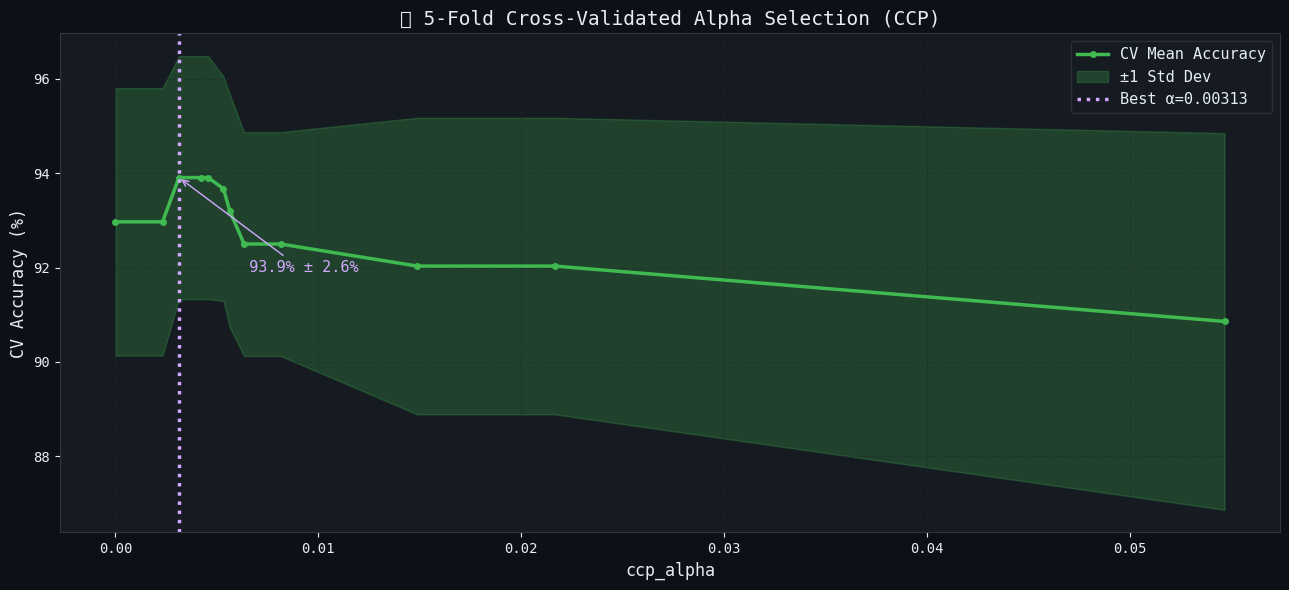

🏆 Using CV prevents test set data leakage during alpha selection!


In [37]:
# ── Plot CV alpha selection ──
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(ccp_alphas, cv_means_, 'o-', color=VAL_C, lw=2.5, ms=4, label='CV Mean Accuracy')
ax.fill_between(ccp_alphas, cv_means_-cv_stds_, cv_means_+cv_stds_,
                alpha=0.25, color=VAL_C, label='±1 Std Dev')
ax.axvline(best_cv_alpha, color=HI_C, ls=':', lw=2.5,
           label=f'Best α={best_cv_alpha:.5f}')
ax.annotate(f' {cv_means_[best_cv_idx]:.1f}% ± {cv_stds_[best_cv_idx]:.1f}%',
            xy=(best_cv_alpha, cv_means_[best_cv_idx]),
            xytext=(best_cv_alpha + 0.003, cv_means_[best_cv_idx] - 2),
            color=HI_C, fontsize=11,
            arrowprops=dict(arrowstyle='->', color=HI_C))
ax.set_xlabel('ccp_alpha', fontsize=12); ax.set_ylabel('CV Accuracy (%)', fontsize=12)
ax.set_title('✅ 5-Fold Cross-Validated Alpha Selection (CCP)', fontsize=14)
ax.legend(fontsize=11); ax.grid(True)
plt.tight_layout()
plt.savefig('/tmp/cv_alpha.png', dpi=130, bbox_inches='tight')
plt.show()
print("🏆 Using CV prevents test set data leakage during alpha selection!")


## 🔁 9. Reduced Error Pruning (REP)

**Reduced Error Pruning** (Quinlan, 1987) is a classic post-pruning algorithm:

```
Algorithm REP:
1. Split data → Train / Validation / Test
2. Grow full tree on Train
3. For each internal node (bottom-up order):
   a. Replace the subtree with a majority-class leaf
   b. Measure validation accuracy
   c. If accuracy doesn't drop → keep the pruning
   d. Else → restore the subtree
4. Repeat until no improvement
```

We simulate this using CCP with validation-set alpha selection.


In [38]:
# ── REP simulation ──
# Split training into sub-train + validation
X_str, X_val_r, y_str, y_val_r = train_test_split(
    X_train, y_train, test_size=0.25, random_state=7
)
print(f"Sub-train : {len(X_str)} | Validation : {len(X_val_r)} | Test : {len(X_test)}")

# Grow full tree on sub-train
full_rep = DecisionTreeClassifier(random_state=42)
full_rep.fit(X_str, y_str)
path_rep    = full_rep.cost_complexity_pruning_path(X_str, y_str)
alphas_rep  = path_rep.ccp_alphas[:-1]

# Select alpha using VALIDATION set (REP spirit)
val_accs_rep = []
for alpha in alphas_rep:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_str, y_str)
    val_accs_rep.append(accuracy_score(y_val_r, clf.predict(X_val_r)))

best_rep_idx   = np.argmax(val_accs_rep)
best_rep_alpha = alphas_rep[best_rep_idx]

# Final REP model
dt_rep = DecisionTreeClassifier(ccp_alpha=best_rep_alpha, random_state=42)
dt_rep.fit(X_str, y_str)

print(f"\n🌿 Reduced Error Pruning — Results")
print(f"   Best Val Alpha    : {best_rep_alpha:.8f}")
print(f"   Val  Accuracy     : {val_accs_rep[best_rep_idx]*100:.2f}%")
print(f"   Test Accuracy     : {accuracy_score(y_test, dt_rep.predict(X_test))*100:.2f}%")
print(f"   Full tree leaves  : {full_rep.get_n_leaves()}")
print(f"   REP tree leaves   : {dt_rep.get_n_leaves()}")
print(f"   Reduction         : {full_rep.get_n_leaves() - dt_rep.get_n_leaves()} leaves removed")


Sub-train : 319 | Validation : 107 | Test : 143

🌿 Reduced Error Pruning — Results
   Best Val Alpha    : 0.00000000
   Val  Accuracy     : 93.46%
   Test Accuracy     : 91.61%
   Full tree leaves  : 12
   REP tree leaves   : 12
   Reduction         : 0 leaves removed


## 🗺️ 10. Decision Boundary Visualization (2D Moons Dataset)

Abstract concepts become concrete when we see them.  
Using `make_moons` (2D synthetic), we can directly visualize how pruning shapes the boundary.

| Model | Expected Boundary |
|-------|-----------------|
| Depth=1 | Straight line — extreme underfitting |
| Depth=3 | Smooth, captures the moon shape |
| Depth=10 | Jagged, noisy — overfitting the training points |
| CCP pruned | Clean, generalizable boundary |


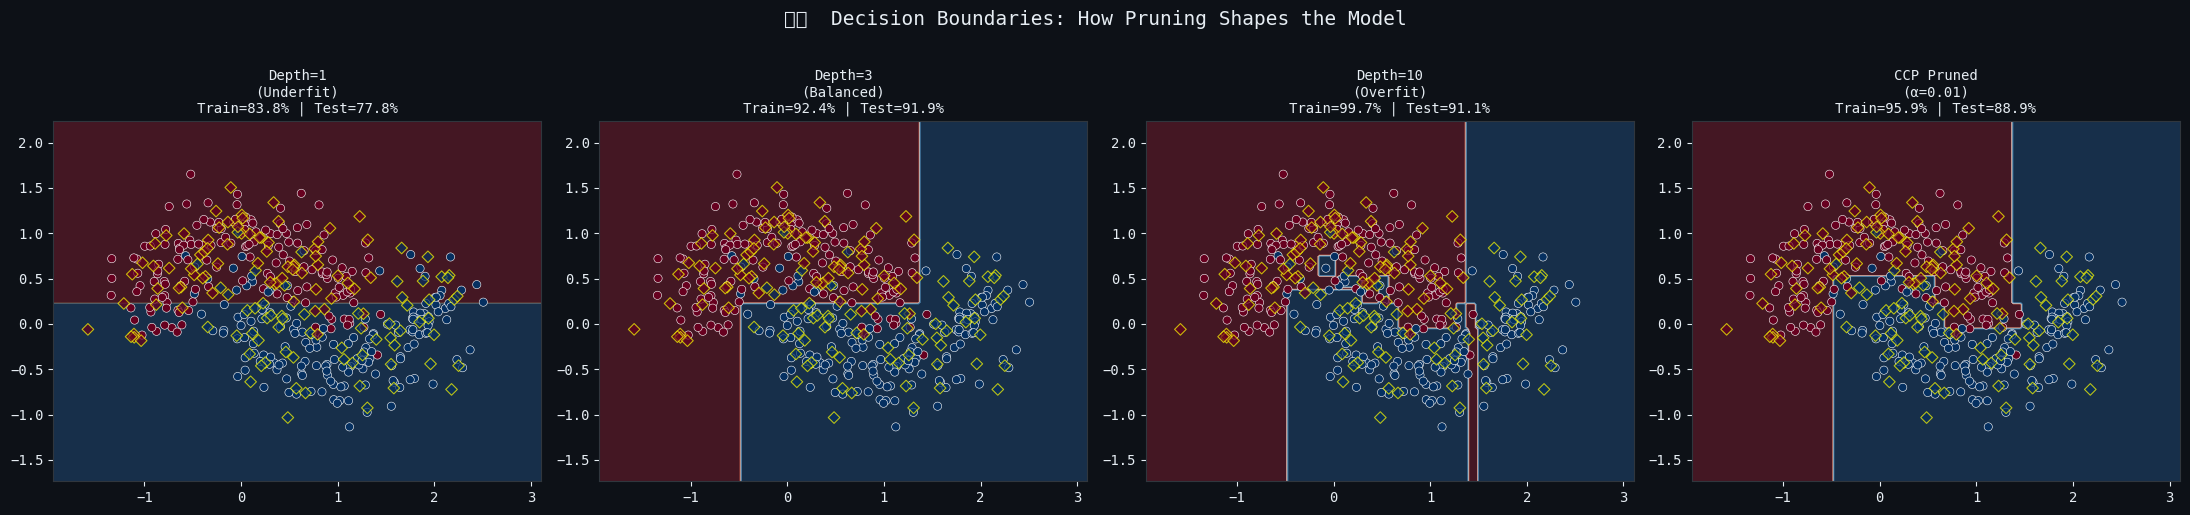

✅ Notice: Depth=10 memorizes training points (jagged boundary)
   Depth=3 and CCP generalize cleanly to unseen data


In [39]:
# ── Moons boundary visualization ──
Xm, ym = make_moons(n_samples=450, noise=0.25, random_state=42)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=42)

def plot_boundary(clf, Xtr, ytr, Xte, yte, ax, title):
    h = 0.025
    x1_min, x1_max = Xtr[:,0].min()-0.6, Xtr[:,0].max()+0.6
    x2_min, x2_max = Xtr[:,1].min()-0.6, Xtr[:,1].max()+0.6
    xx, yy = np.meshgrid(np.arange(x1_min, x1_max, h),
                         np.arange(x2_min, x2_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap='RdBu')
    ax.scatter(Xtr[:,0], Xtr[:,1], c=ym_tr, cmap='RdBu',
               edgecolors='w', lw=0.4, s=35, label='Train')
    ax.scatter(Xm_te[:,0], Xm_te[:,1], c=ym_te, cmap='RdBu',
               edgecolors='yellow', lw=0.8, s=35, marker='D', alpha=0.7, label='Test')
    tr = accuracy_score(ym_tr, clf.predict(Xm_tr))
    te = accuracy_score(ym_te, clf.predict(Xm_te))
    ax.set_title(f"{title}\nTrain={tr*100:.1f}% | Test={te*100:.1f}%", fontsize=10)
    ax.set_facecolor('#161b22')

configs_db = [
    ('Depth=1\n(Underfit)',  DecisionTreeClassifier(max_depth=1,    random_state=42)),
    ('Depth=3\n(Balanced)',  DecisionTreeClassifier(max_depth=3,    random_state=42)),
    ('Depth=10\n(Overfit)',  DecisionTreeClassifier(max_depth=10,   random_state=42)),
    ('CCP Pruned\n(α=0.01)', DecisionTreeClassifier(ccp_alpha=0.01, random_state=42)),
]
[clf.fit(Xm_tr, ym_tr) for _, clf in configs_db]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('🗺️  Decision Boundaries: How Pruning Shapes the Model', fontsize=14, y=1.02)
for ax, (title, clf) in zip(axes, configs_db):
    plot_boundary(clf, Xm_tr, ym_tr, Xm_te, ym_te, ax, title)
plt.tight_layout()
plt.savefig('/tmp/boundaries.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Notice: Depth=10 memorizes training points (jagged boundary)")
print("   Depth=3 and CCP generalize cleanly to unseen data")


## 📏 11. min_impurity_decrease — Principled Pre-Pruning

`min_impurity_decrease` stops a split if the **weighted impurity reduction** is below threshold:

$$\Delta I = I(\text{parent}) - \frac{N_L}{N} I(L) - \frac{N_R}{N} I(R) \geq \text{threshold}$$

This is mathematically principled: splits must earn their place by reducing impurity significantly.


 threshold  train_acc  test_acc  leaves  depth
    0.0000     100.00     92.31      18      7
    0.0005      99.77     93.71      16      6
    0.0010      99.77     93.71      16      6
    0.0050      98.59     95.10       9      4
    0.0100      97.18     94.41       5      3
    0.0200      95.77     90.91       4      2
    0.0500      94.60     91.61       3      2
    0.1000      92.25     92.31       2      1


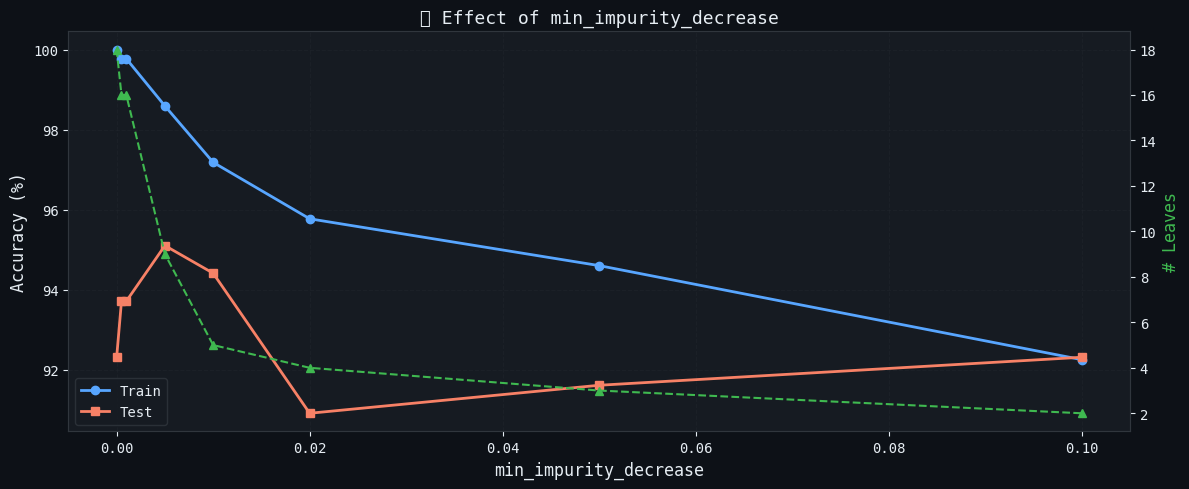

In [40]:
# ── Sweep min_impurity_decrease ──
thresholds_mid = [0.0, 0.0005, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
mid_rows = []

for t in thresholds_mid:
    clf = DecisionTreeClassifier(min_impurity_decrease=t, random_state=42)
    clf.fit(X_train, y_train)
    mid_rows.append({
        'threshold':  t,
        'train_acc':  round(accuracy_score(y_train, clf.predict(X_train))*100, 2),
        'test_acc':   round(accuracy_score(y_test,  clf.predict(X_test)) *100, 2),
        'leaves':     clf.get_n_leaves(),
        'depth':      clf.get_depth(),
    })

df_mid = pd.DataFrame(mid_rows)
print(df_mid.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds_mid, df_mid['train_acc'], 'o-', color=TRAIN_C, lw=2, label='Train')
ax.plot(thresholds_mid, df_mid['test_acc'],  's-', color=TEST_C,  lw=2, label='Test')
ax2 = ax.twinx()
ax2.plot(thresholds_mid, df_mid['leaves'], '^--', color=VAL_C, lw=1.5, label='# Leaves')
ax2.set_ylabel('# Leaves', color=VAL_C, fontsize=12)
ax.set_xlabel('min_impurity_decrease', fontsize=12); ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('📏 Effect of min_impurity_decrease', fontsize=13)
ax.legend(loc='lower left'); ax.grid(True)
plt.tight_layout()
plt.savefig('/tmp/mid.png', dpi=130, bbox_inches='tight')
plt.show()


## 🔢 12. Feature Importance: Pruned vs Full Tree

Feature importance = total weighted impurity reduction across all splits using that feature.  
Pruned trees focus on **fewer, more powerful** features. This improves interpretability.


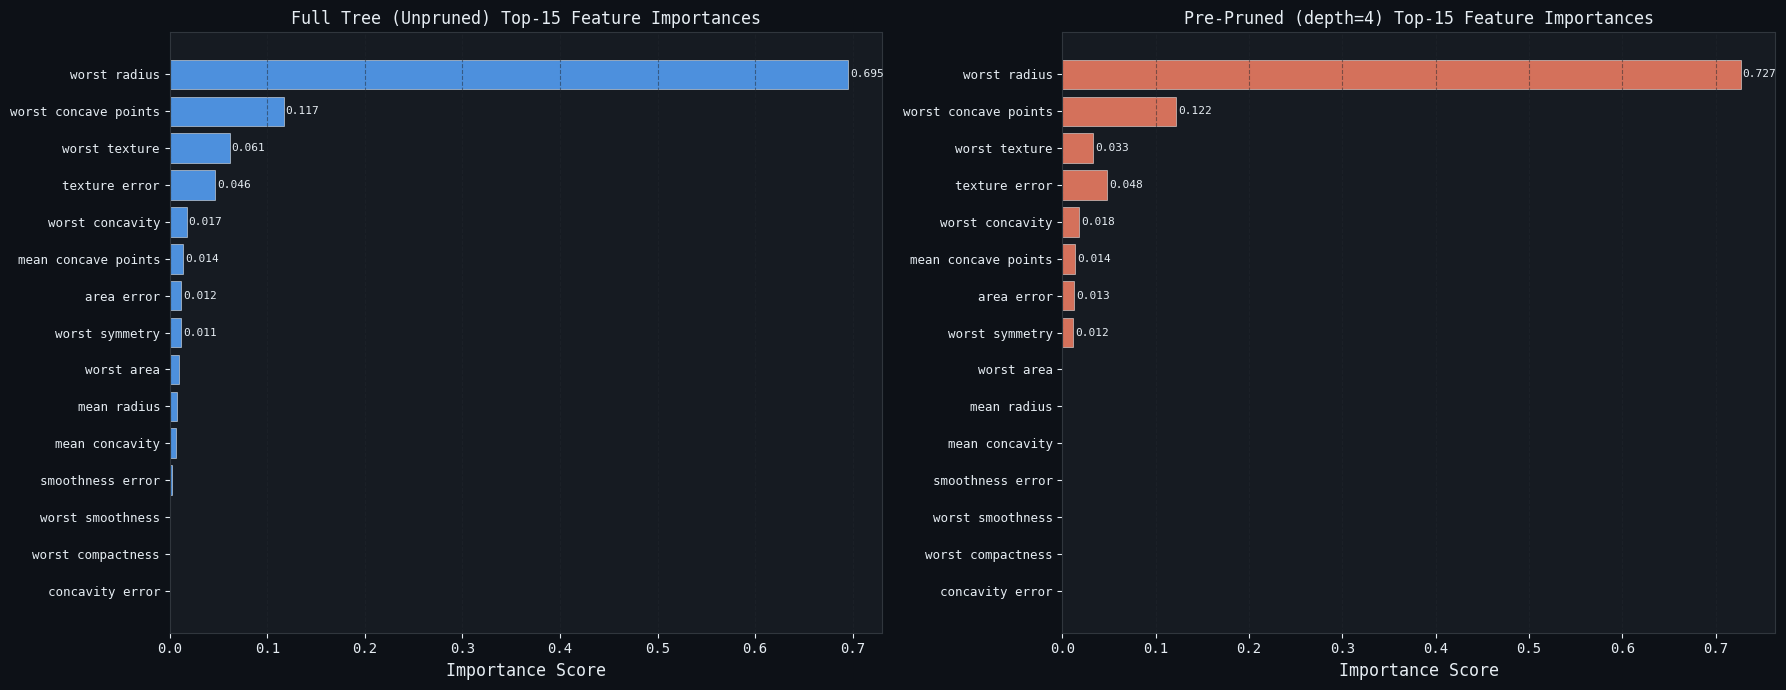

Full tree uses  : 12 features
Pruned tree uses:  9 features
Top feature (both): 'worst radius'


In [41]:
# ── Feature importances comparison ──
dt_f = DecisionTreeClassifier(random_state=42)
dt_f.fit(X_train, y_train)

dt_p = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_p.fit(X_train, y_train)

fi_f = dt_f.feature_importances_
fi_p = dt_p.feature_importances_

# Top 15 by full tree importance
idx15 = np.argsort(fi_f)[-15:]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, fi, title, color in zip(
    axes,
    [fi_f[idx15], fi_p[idx15]],
    ['Full Tree (Unpruned) Top-15 Feature Importances',
     'Pre-Pruned (depth=4) Top-15 Feature Importances'],
    [TRAIN_C, TEST_C]
):
    bars = ax.barh(range(len(idx15)), fi, color=color, alpha=0.85,
                   edgecolor='white', lw=0.4)
    ax.set_yticks(range(len(idx15)))
    ax.set_yticklabels([feature_names[i] for i in idx15], fontsize=9)
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.grid(True, axis='x')
    
    # Annotate bars
    for bar, v in zip(bars, fi):
        if v > 0.01:
            ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/feat_imp.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Full tree uses  : {np.sum(fi_f > 0):2d} features")
print(f"Pruned tree uses: {np.sum(fi_p > 0):2d} features")
print(f"Top feature (both): '{feature_names[np.argmax(fi_p)]}'")

## 📈 13. Validation Curve — Built-in sklearn Tool

`validation_curve` is the cleanest way to sweep one hyperparameter.  
It handles the cross-validation internally and returns mean ± std for each value.

This is what you should do **before** any deployment decision.


Optimal depth (CV): 2
CV Accuracy       : 92.80% ± 1.01%


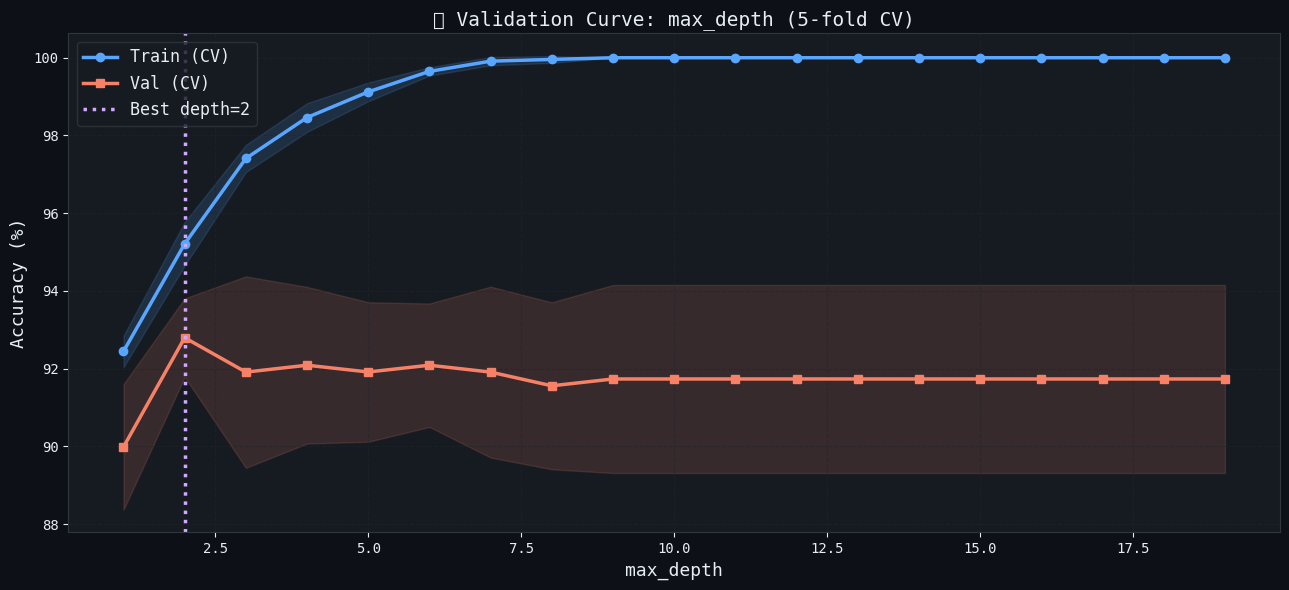

In [42]:
# ── Validation Curve: max_depth ──
param_range = np.arange(1, 20)
tr_vc, te_vc = validation_curve(
    DecisionTreeClassifier(random_state=42), X, y,
    param_name='max_depth', param_range=param_range,
    cv=5, scoring='accuracy', n_jobs=-1
)
tr_m_vc = tr_vc.mean(axis=1)*100; tr_s_vc = tr_vc.std(axis=1)*100
te_m_vc = te_vc.mean(axis=1)*100; te_s_vc = te_vc.std(axis=1)*100

best_vc_d = param_range[np.argmax(te_m_vc)]
print(f"Optimal depth (CV): {best_vc_d}")
print(f"CV Accuracy       : {te_m_vc.max():.2f}% ± {te_s_vc[np.argmax(te_m_vc)]:.2f}%")

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(param_range, tr_m_vc, 'o-', color=TRAIN_C, lw=2.5, label='Train (CV)', ms=6)
ax.fill_between(param_range, tr_m_vc-tr_s_vc, tr_m_vc+tr_s_vc, alpha=0.15, color=TRAIN_C)
ax.plot(param_range, te_m_vc, 's-', color=TEST_C,  lw=2.5, label='Val (CV)',   ms=6)
ax.fill_between(param_range, te_m_vc-te_s_vc, te_m_vc+te_s_vc, alpha=0.15, color=TEST_C)
ax.axvline(best_vc_d, color=HI_C, ls=':', lw=2.5, label=f'Best depth={best_vc_d}')
ax.set_xlabel('max_depth', fontsize=13); ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('📈 Validation Curve: max_depth (5-fold CV)', fontsize=14)
ax.legend(fontsize=12); ax.grid(True)
plt.tight_layout()
plt.savefig('/tmp/val_curve.png', dpi=130, bbox_inches='tight')
plt.show()


## 📚 14. Learning Curves — Diagnosing Bias vs Variance from Data Size

**Learning curves** reveal whether your model suffers from bias or variance by varying training set size:

```
High Bias  → Train ≈ Val, both plateau LOW  → Need better model / more features
High Var   → Train >> Val, gap stays large  → Need more data or regularization
Good Fit   → Train ≈ Val, both HIGH         → 🏆 Deploy!
```


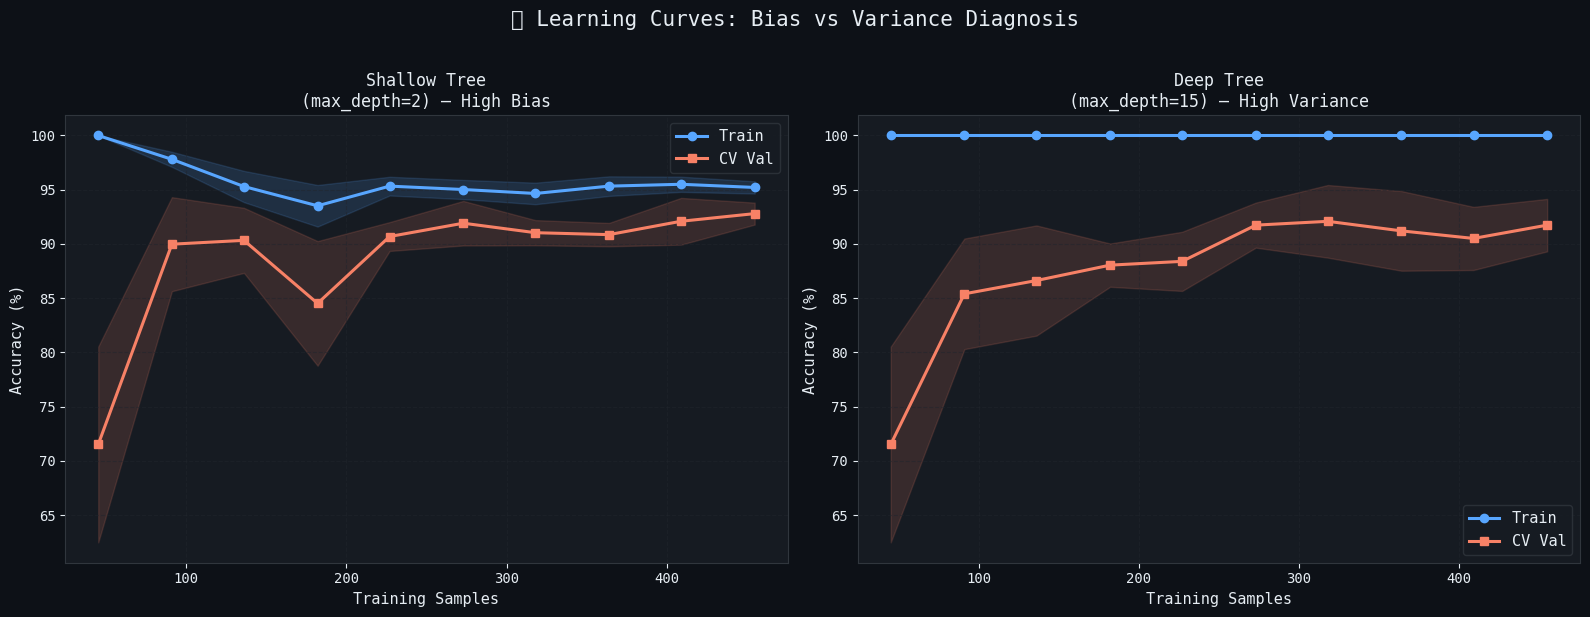

Left  → High Bias: both curves converge LOW → model too simple
Right → High Variance: train >> val, gap stays wide → model too complex


In [43]:
# ── Learning Curves ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
configs_lc = [
    ('Shallow Tree\n(max_depth=2) — High Bias', DecisionTreeClassifier(max_depth=2, random_state=42)),
    ('Deep Tree\n(max_depth=15) — High Variance', DecisionTreeClassifier(max_depth=15,random_state=42)),
]

for ax, (title, clf) in zip(axes, configs_lc):
    sizes, tr_s, val_s = learning_curve(
        clf, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', n_jobs=-1
    )
    tr_m, tr_s_ = tr_s.mean(axis=1)*100,  tr_s.std(axis=1)*100
    vl_m, vl_s_ = val_s.mean(axis=1)*100, val_s.std(axis=1)*100
    ax.plot(sizes, tr_m, 'o-', color=TRAIN_C, lw=2.2, label='Train')
    ax.fill_between(sizes, tr_m-tr_s_, tr_m+tr_s_, alpha=0.15, color=TRAIN_C)
    ax.plot(sizes, vl_m, 's-', color=TEST_C,  lw=2.2, label='CV Val')
    ax.fill_between(sizes, vl_m-vl_s_, vl_m+vl_s_, alpha=0.15, color=TEST_C)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Training Samples', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.legend(fontsize=11); ax.grid(True)

plt.suptitle('📚 Learning Curves: Bias vs Variance Diagnosis', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/lc.png', dpi=130, bbox_inches='tight')
plt.show()
print("Left  → High Bias: both curves converge LOW → model too simple")
print("Right → High Variance: train >> val, gap stays wide → model too complex")


## 🏆 15. Final Head-to-Head Comparison

Bringing everything together — all pruning strategies evaluated on the same test set.


In [44]:
# ── Final showdown ──
final_models = {
    '1. Unpruned':                DecisionTreeClassifier(random_state=42),
    '2. Pre: max_depth=4':        DecisionTreeClassifier(max_depth=4, random_state=42),
    '3. Pre: depth+min_leaf':     DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42),
    '4. Pre: min_impurity=0.01':  DecisionTreeClassifier(min_impurity_decrease=0.01, random_state=42),
    '5. Post: CCP (CV-α)':        DecisionTreeClassifier(ccp_alpha=best_cv_alpha, random_state=42),
    '6. Post: REP (Val-α)':       DecisionTreeClassifier(ccp_alpha=best_rep_alpha, random_state=42),
}

final_rows = []
for name, clf in final_models.items():
    clf.fit(X_train, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train))
    te = accuracy_score(y_test,  clf.predict(X_test))
    cv = cross_val_score(clf, X_train, y_train, cv=5).mean()
    final_rows.append({
        'Model': name, 'Train%': f"{tr*100:.2f}",
        'Test%': f"{te*100:.2f}", 'CV5%': f"{cv*100:.2f}",
        'Gap%': f"{(tr-te)*100:.2f}", 'Depth': clf.get_depth(),
        'Leaves': clf.get_n_leaves()
    })

df_final = pd.DataFrame(final_rows)
print(df_final.to_string(index=False))
print("\n🥇 Best test accuracy method highlighted above.")
best_name = df_final.loc[df_final['Test%'].astype(float).idxmax(), 'Model']
print(f"   Winner: {best_name}")


                    Model Train% Test%  CV5% Gap%  Depth  Leaves
              1. Unpruned 100.00 92.31 92.97 7.69      7      18
      2. Pre: max_depth=4  98.83 94.41 92.26 4.42      4      11
   3. Pre: depth+min_leaf  97.65 93.01 93.20 4.65      4      10
4. Pre: min_impurity=0.01  97.18 94.41 92.73 2.78      3       5
      5. Post: CCP (CV-α)  99.06 93.71 93.91 5.35      5      11
     6. Post: REP (Val-α) 100.00 92.31 92.97 7.69      7      18

🥇 Best test accuracy method highlighted above.
   Winner: 2. Pre: max_depth=4


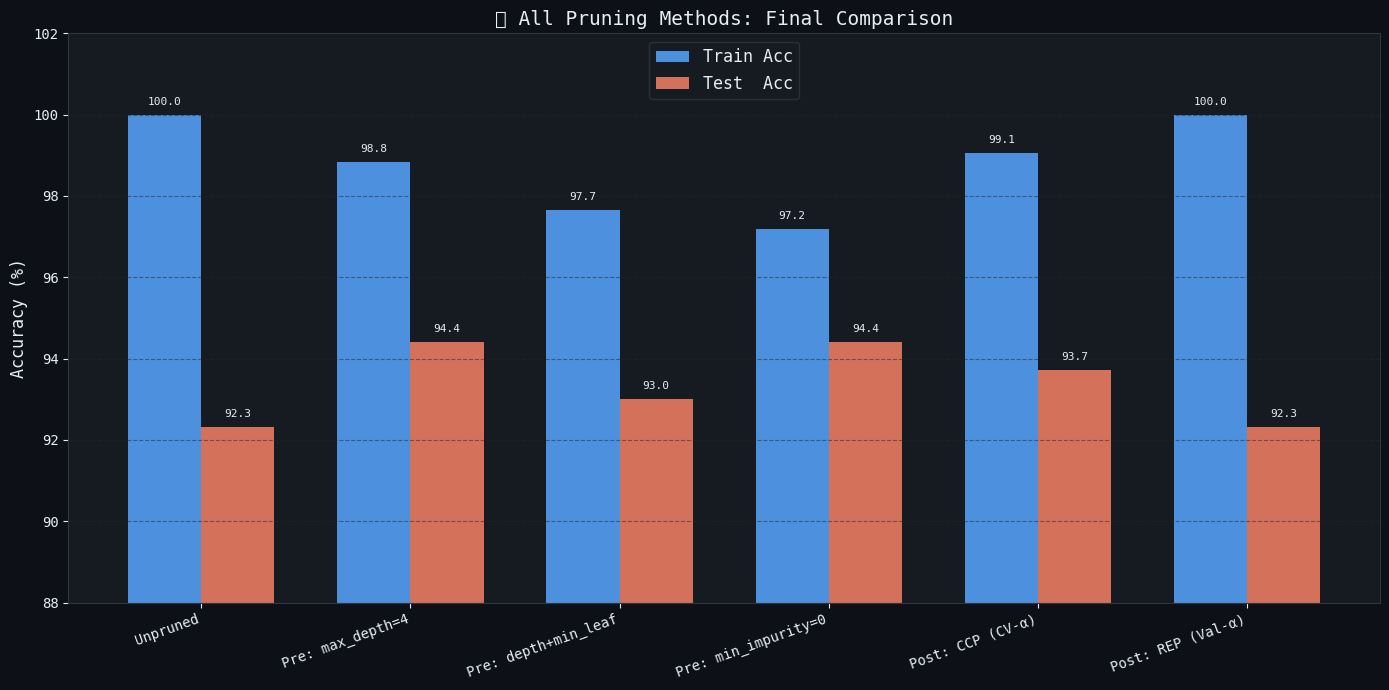

In [45]:
# ── Final bar chart ──
models_labels = [r['Model'].split('.')[1].strip() for r in final_rows]
train_vals = [float(r['Train%']) for r in final_rows]
test_vals  = [float(r['Test%'])  for r in final_rows]

x  = np.arange(len(final_rows))
w  = 0.35
fig, ax = plt.subplots(figsize=(14, 7))
b1 = ax.bar(x - w/2, train_vals, w, label='Train Acc', color=TRAIN_C, alpha=0.85)
b2 = ax.bar(x + w/2, test_vals,  w, label='Test  Acc', color=TEST_C,  alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(models_labels, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('🏆 All Pruning Methods: Final Comparison', fontsize=14)
ax.legend(fontsize=12); ax.grid(True, axis='y'); ax.set_ylim(88, 102)
plt.tight_layout()
plt.savefig('/tmp/final_bar.png', dpi=130, bbox_inches='tight')
plt.show()


## 🎓 16. Key Takeaways & Best Practices

---

### ⚖️ The Bias-Variance Tradeoff in One Table

| Depth | Bias | Variance | Behavior |
|-------|------|----------|----------|
| 1–2 | Very High | Near Zero | Underfits — too simple |
| 3–5 | Low | Low | ✅ Sweet spot |
| 7+ | Near Zero | Very High | Overfits — memorizes |

---

### 🪓 Pruning Strategy Guide

| Situation | Recommended Approach |
|-----------|---------------------|
| Quick prototype | `max_depth=4-6` |
| Noisy data | `min_samples_leaf=10-20` |
| Best accuracy needed | CCP with 5-fold CV |
| Limited data | REP (uses validation set) |
| Interpretability critical | Combine depth + min_leaf |

---

### 🔑 CCP Formula Recap

$$\text{Prune if: } \frac{R(t) - R(T_t)}{|T_t| - 1} < \alpha$$

The left side is the **effective alpha** — the rate of impurity gain per leaf removed.

---

### 🚀 Coming Up in Notebook 04...

> **Random Forests**: Instead of pruning ONE tree, we'll train **hundreds of diverse trees**  
> and aggregate their predictions. This eliminates variance almost entirely while keeping bias low.
> 
> Key ideas: **Bagging** · **Feature Randomness** · **OOB Error** · **Ensemble Power**


In [46]:
# ── Notebook 03 Final Summary ──
print("=" * 60)
print("   📓 NOTEBOOK 03 — PRUNING & COMPLEXITY")
print("   COMPLETE SUMMARY")
print("=" * 60)
print(f"   Dataset          : Breast Cancer Wisconsin (569 × 30)")
print()
print("   RESULTS RECAP:")
print(f"   {'Method':<30} {'Test Acc':>9}")
print("   " + "-"*41)
for row in final_rows:
    marker = " 🏆" if row['Model'] == best_name else ""
    print(f"   {row['Model']:<30} {row['Test%']:>8}%{marker}")
print("=" * 60)
print()
print("   KEY LESSONS:")
print("   ✅ Unpruned trees = 100% train, ~92% test (overfit)")
print("   ✅ Pre-pruning is fast but horizon-limited")
print("   ✅ CCP (post-pruning) gives best generalization")
print("   ✅ Always select alpha via CV, not test set")
print("   ✅ The bias-variance tradeoff is real and measurable")
print()
print("   🚀 Next: Notebook 04 — Random Forests")
print("   Bagging + Feature Randomness = Zero Variance!")
print("=" * 60)


   📓 NOTEBOOK 03 — PRUNING & COMPLEXITY
   COMPLETE SUMMARY
   Dataset          : Breast Cancer Wisconsin (569 × 30)

   RESULTS RECAP:
   Method                          Test Acc
   -----------------------------------------
   1. Unpruned                       92.31%
   2. Pre: max_depth=4               94.41% 🏆
   3. Pre: depth+min_leaf            93.01%
   4. Pre: min_impurity=0.01         94.41%
   5. Post: CCP (CV-α)               93.71%
   6. Post: REP (Val-α)              92.31%

   KEY LESSONS:
   ✅ Unpruned trees = 100% train, ~92% test (overfit)
   ✅ Pre-pruning is fast but horizon-limited
   ✅ CCP (post-pruning) gives best generalization
   ✅ Always select alpha via CV, not test set
   ✅ The bias-variance tradeoff is real and measurable

   🚀 Next: Notebook 04 — Random Forests
   Bagging + Feature Randomness = Zero Variance!
